In [1]:
import networkx as nx
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.offsetbox import OffsetImage, AnnotationBbox
import matplotlib.image as mpimg

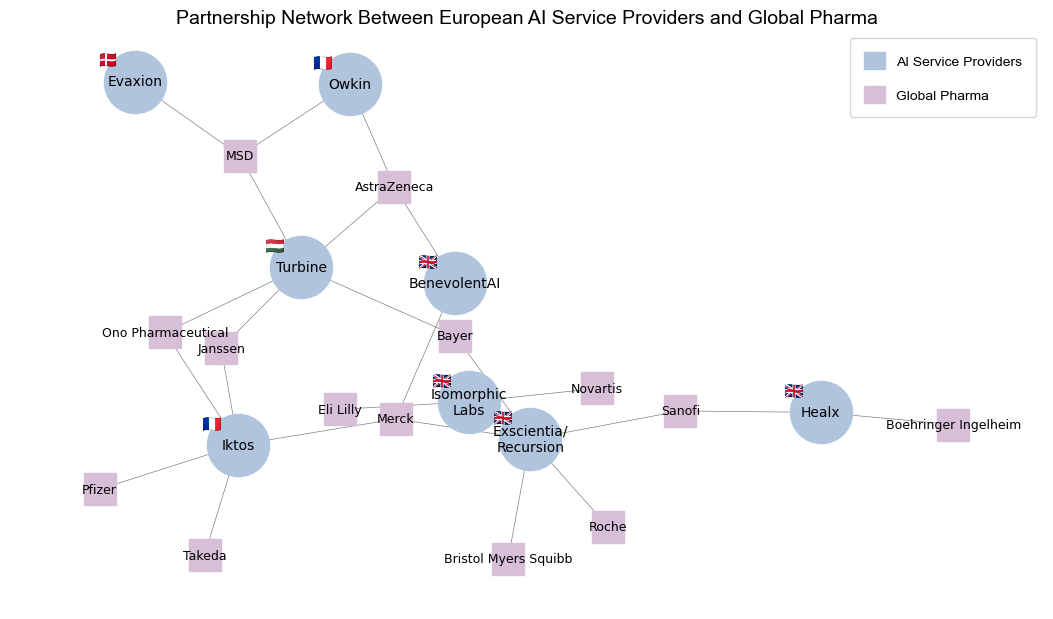

In [2]:
# Create graph
G = nx.Graph()

# AI service providers
ai_pharma = [
    'Exscientia/Recursion', 'BenevolentAI', 'Healx',
    'Isomorphic Labs', 'Owkin', 'Iktos', 'Evaxion', 'Turbine'
]

# Global pharma companies
big_pharma = [
    'Merck', 'Sanofi', 'AstraZeneca', 'MSD', 'Pfizer', 'Takeda',
    'Janssen', 'Bristol Myers Squibb', 'Bayer', 'Eli Lilly',
    'Novartis', 'Ono Pharmaceutical', 'Boehringer Ingelheim', 'Roche'
]

# Partnerships
edges = [
    ('Exscientia/Recursion', 'Merck'),
    ('Exscientia/Recursion', 'Sanofi'),
    ('Exscientia/Recursion', 'Bristol Myers Squibb'),
    ('Exscientia/Recursion', 'Roche'),
    ('Exscientia/Recursion', 'Bayer'),
    ('BenevolentAI', 'AstraZeneca'),
    ('BenevolentAI', 'Merck'),
    ('Healx', 'Sanofi'),
    ('Healx', 'Boehringer Ingelheim'),
    ('Isomorphic Labs', 'Eli Lilly'),
    ('Isomorphic Labs', 'Novartis'),
    ('Owkin', 'MSD'),
    ('Owkin', 'AstraZeneca'),
    ('Turbine', 'MSD'),
    ('Turbine', 'Janssen'),
    ('Turbine', 'AstraZeneca'),
    ('Turbine', 'Bayer'),
    ('Turbine', 'Ono Pharmaceutical'),
    ('Iktos', 'Merck'),
    ('Iktos', 'Pfizer'),
    ('Iktos', 'Takeda'),
    ('Iktos', 'Janssen'),
    ('Iktos', 'Ono Pharmaceutical'),
    ('Evaxion', 'MSD')
]

# Add nodes and edges
G.add_nodes_from(ai_pharma, bipartite='ai')
G.add_nodes_from(big_pharma, bipartite='big')
G.add_edges_from(edges)

# Layout
pos = nx.kamada_kawai_layout(G)

# Split node groups
ai_nodes = [n for n in G.nodes if G.nodes[n]['bipartite'] == 'ai']
big_nodes = [n for n in G.nodes if G.nodes[n]['bipartite'] == 'big']

# Custom labels for selected AI companies
ai_labels = {
    'Isomorphic Labs': 'Isomorphic\nLabs',
    'Exscientia/Recursion': 'Exscientia/\nRecursion'
}
ai_labels.update({n: n for n in ai_nodes if n not in ai_labels})

# Flag function
def add_flag(ax, node_name, flag_path, offset=(-0.05, 0.05), zoom=0.4):
    if node_name in pos:
        img = mpimg.imread(flag_path)
        imagebox = OffsetImage(img, zoom=zoom)
        node_pos = pos[node_name]
        ab = AnnotationBbox(
            imagebox,
            (node_pos[0] + offset[0], node_pos[1] + offset[1]),
            frameon=False
        )
        ax.add_artist(ab)

# Flag paths
ai_company_flags = {
    'Isomorphic Labs': '/Users/yalin/Desktop/TBP/Top 5 RD intensity/Network/gb.png',
    'Healx': '/Users/yalin/Desktop/TBP/Top 5 RD intensity/Network/gb.png',
    'Exscientia/Recursion': '/Users/yalin/Desktop/TBP/Top 5 RD intensity/Network/gb.png',
    'Owkin': '/Users/yalin/Desktop/TBP/Top 5 RD intensity/Network/mf.png',
    'Turbine': '/Users/yalin/Desktop/TBP/Top 5 RD intensity/Network/hu.png',
    'Evaxion': '/Users/yalin/Desktop/TBP/Top 5 RD intensity/Network/dk.png',
    'BenevolentAI': '/Users/yalin/Desktop/TBP/Top 5 RD intensity/Network/gb.png',
    'Iktos': '/Users/yalin/Desktop/TBP/Top 5 RD intensity/Network/mf.png'
}

# Plot
plt.rcParams['font.family'] = 'Arial'
plt.figure(figsize=(13.33, 7.5))

nx.draw_networkx_edges(G, pos, width=0.5, alpha=0.5)

nx.draw_networkx_nodes(
    G, pos,
    nodelist=ai_nodes,
    node_color='lightsteelblue',
    node_shape='o',
    node_size=2000
)

nx.draw_networkx_nodes(
    G, pos,
    nodelist=big_nodes,
    node_color='thistle',
    node_shape='s',
    node_size=500
)

nx.draw_networkx_labels(
    G, pos,
    labels=ai_labels,
    font_size=10,
    font_weight='normal'
)

nx.draw_networkx_labels(
    G, pos,
    labels={n: n for n in big_nodes},
    font_size=9,
    font_weight='light'
)

# Add legend
ai_patch = mpatches.Circle((0, 0), radius=0.15, color='lightsteelblue', label='AI Service Providers')
big_patch = mpatches.Rectangle((0, 0), 0.3, 0.3, color='thistle', label='Global Pharma')

plt.legend(
    handles=[ai_patch, big_patch],
    loc='upper right',
    fontsize=10,
    handlelength=1.5,
    handleheight=1.5,
    labelspacing=1.2,
    borderpad=1.0,
    frameon=True
)

plt.title('Partnership Network Between European AI Service Providers and Global Pharma', fontsize=14)
plt.axis('off')

# Add flags
ax = plt.gca()
for company, flag_path in ai_company_flags.items():
    add_flag(ax, company, flag_path)

plt.savefig('network_visualization.png', dpi=300, bbox_inches='tight')
plt.show()